# Performance Evaluation

comparison of five outlier detection algorithms across all datasets.

results are loaded from pre-computed `results/performance/<dataset>/results.csv` files.

Algorithms: One-Class SVM, Isolation Forest, LOF, DBSCAN, ECOD  
Metrics: AUC-ROC, AUC-PR, F1, Precision, Recall


In [4]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import src.utils
importlib.reload(src.utils)

from src.utils import load_results_csv, mean_performance, plot_metric_heatmap, plot_mean_performance, plot_radar, show_dataset_summary

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130})

METRICS = ['auc_roc', 'auc_pr', 'f1', 'precision', 'recall']
METRIC_LABELS = {'auc_roc': 'AUC-ROC', 'auc_pr': 'AUC-PR', 'f1': 'F1', 'precision': 'Precision', 'recall': 'Recall'}


## Load Results

In [5]:
all_results = load_results_csv('results/performance')

print(f'Loaded {len(all_results)} datasets:')
for ds, df in all_results.items():
    print(f'  {ds:35s}  detectors={list(df.index)}')


Loaded 12 datasets:
  graves_ring_outliers                 detectors=['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
  wut_x2                               detectors=['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
  cardio                               detectors=['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
  graves_fuzzyx                        detectors=['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
  shuttle                              detectors=['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
  fcps_target                          detectors=['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
  graves_zigzag_outliers               detectors=['One-Class SVM', 'Isolation Forest', 'Local Outlier Factor', 'DBSCAN', 'ECOD']
  satellite                            detectors=['One-Class SVM', 'Isolation

## AUC-ROC & F1 Heatmaps — All Datasets x All Detectors

Each cell shows the metric score for one algorithm on one dataset. Immediately reveals which algorithm wins where and which datasets are universally hard.


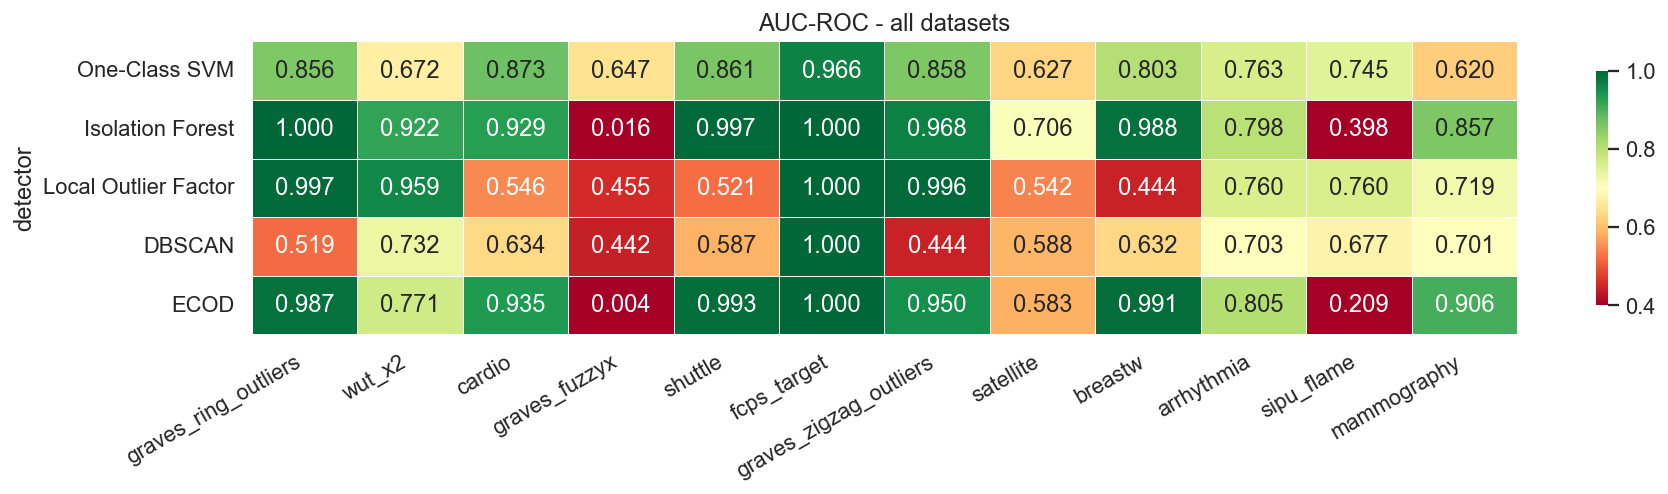

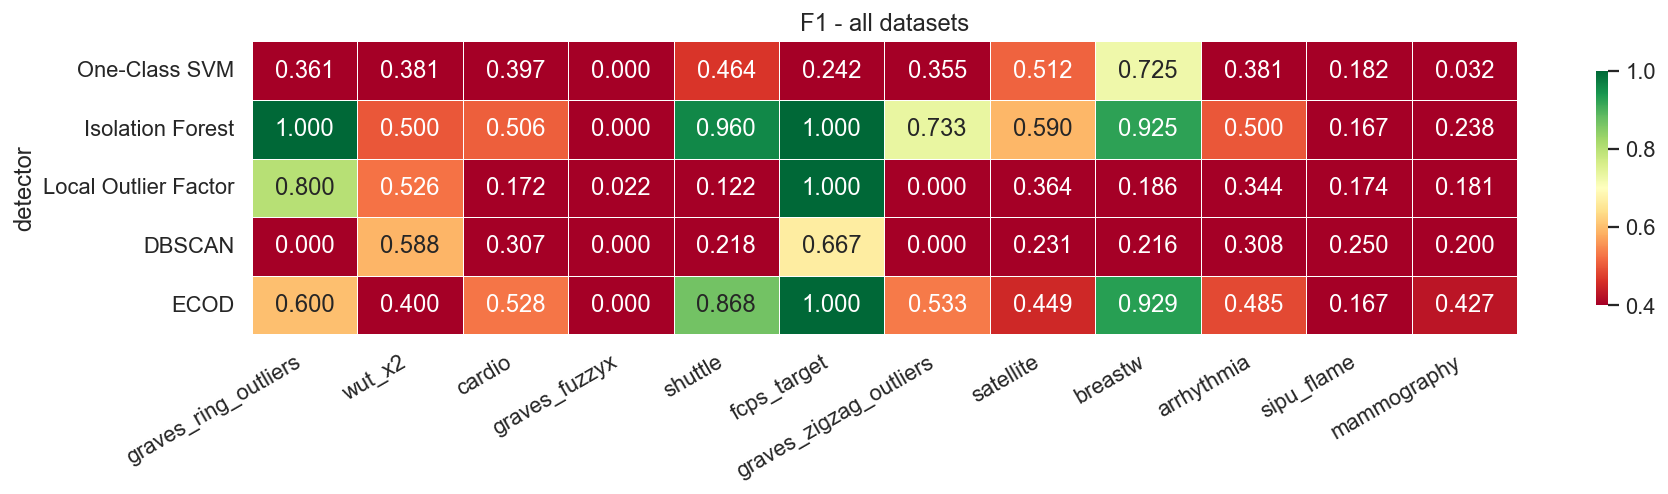

In [6]:
fig = plot_metric_heatmap(all_results, metric='auc_roc', title='AUC-ROC - all datasets')
plt.show()
fig = plot_metric_heatmap(all_results, metric='f1', title='F1 - all datasets')
plt.show()


## Mean Performance Across All Datasets

averaged over all datasets - gives a single ranking per algorithm.


,auc_roc,auc_roc_std,auc_pr,auc_pr_std,f1,f1_std
detector,,,,,,
Isolation Forest,0.7983,0.3018,0.6116,0.3333,0.5933,0.3411
One-Class SVM,0.7742,0.1134,0.3593,0.1850,0.3360,0.2012
ECOD,0.7612,0.3322,0.5499,0.2999,0.5322,0.2936
Local Outlier Factor,0.7249,0.2215,0.4357,0.3461,0.3243,0.3087
DBSCAN,0.6382,0.1492,0.3304,0.2650,0.2486,0.2104


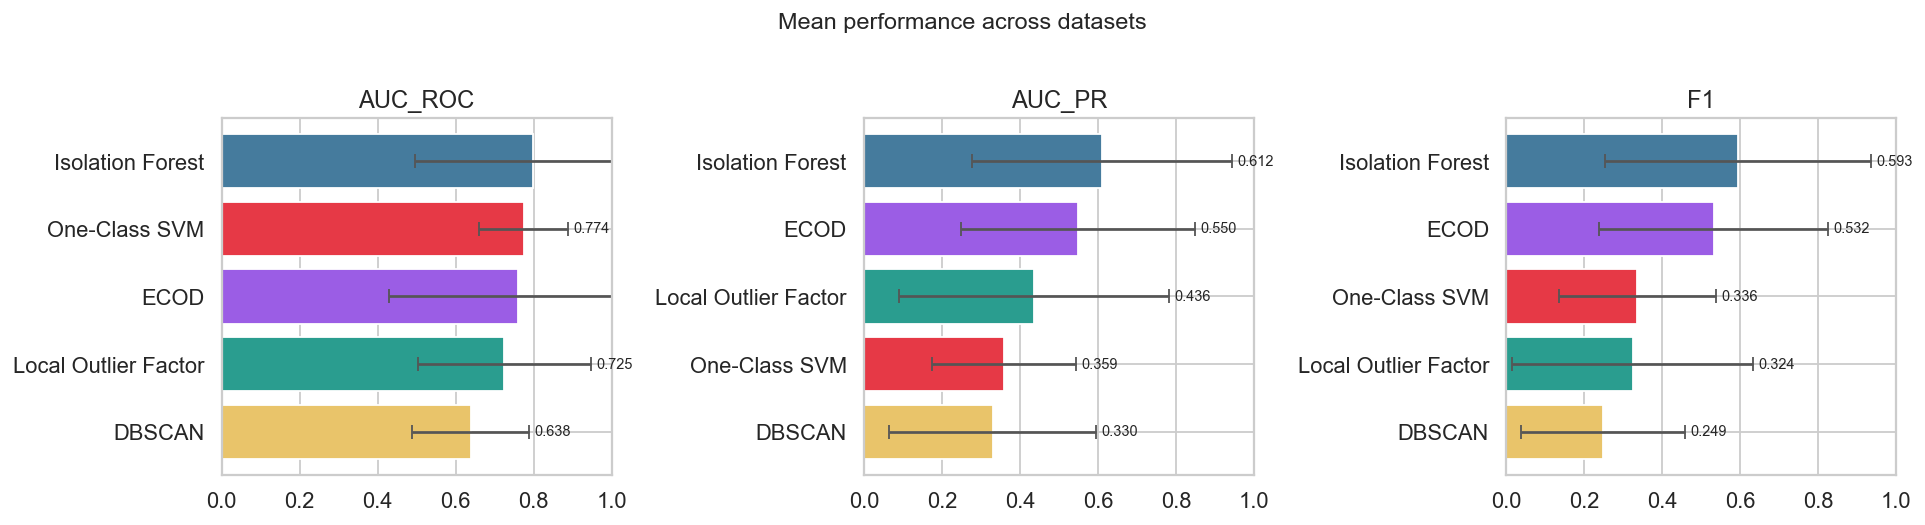

In [7]:
mean_df = mean_performance(all_results, include_std=True)
display(mean_df.style.format('{:.4f}'))
fig = plot_mean_performance(mean_df)
plt.show()

## Radar Chart - Algorithm Profiles

shows the shape of each algorithm's strengths: an algorithm with high AUC-ROC but low precision/recall has a different failure mode than one that is balanced.


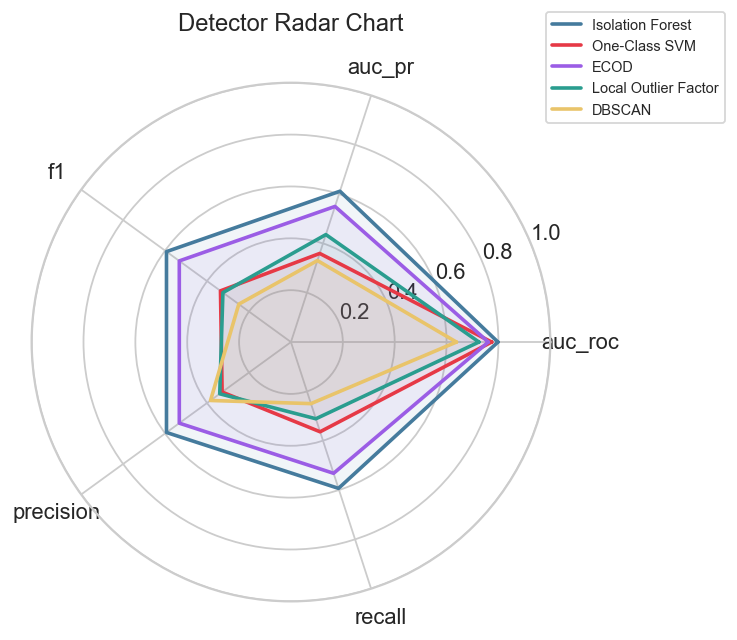

In [15]:
mean_full = mean_performance(all_results, metrics=['auc_roc', 'auc_pr', 'f1', 'precision', 'recall'])
fig = plot_radar(mean_full)
plt.show()


## Per-Dataset Summaries

ROC curves, metric bars, and score distributions for each dataset. 

clustering datasets also include a scatter plot with anomaly labels.


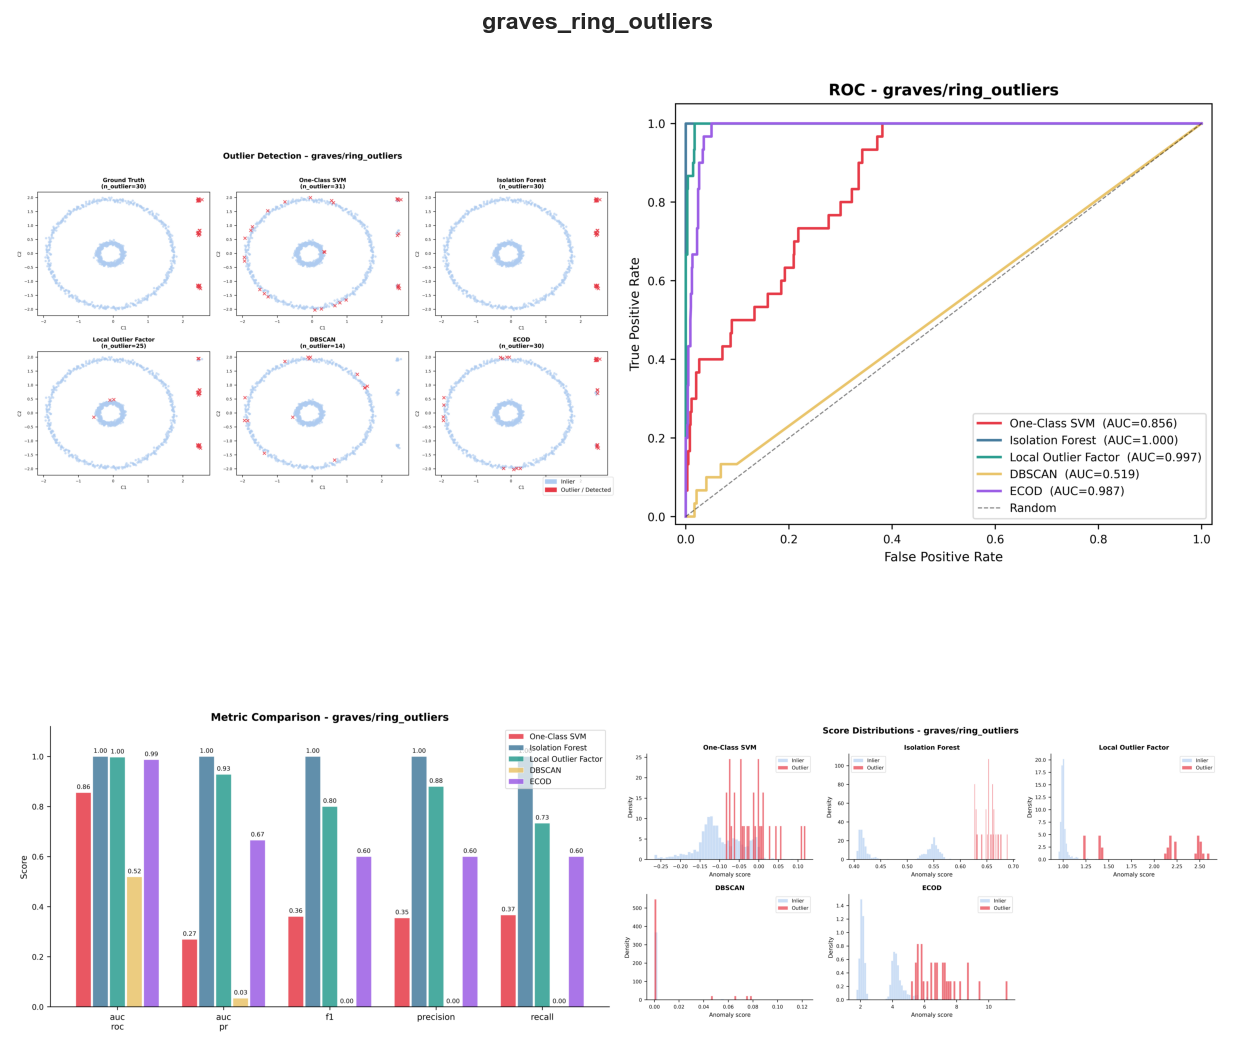

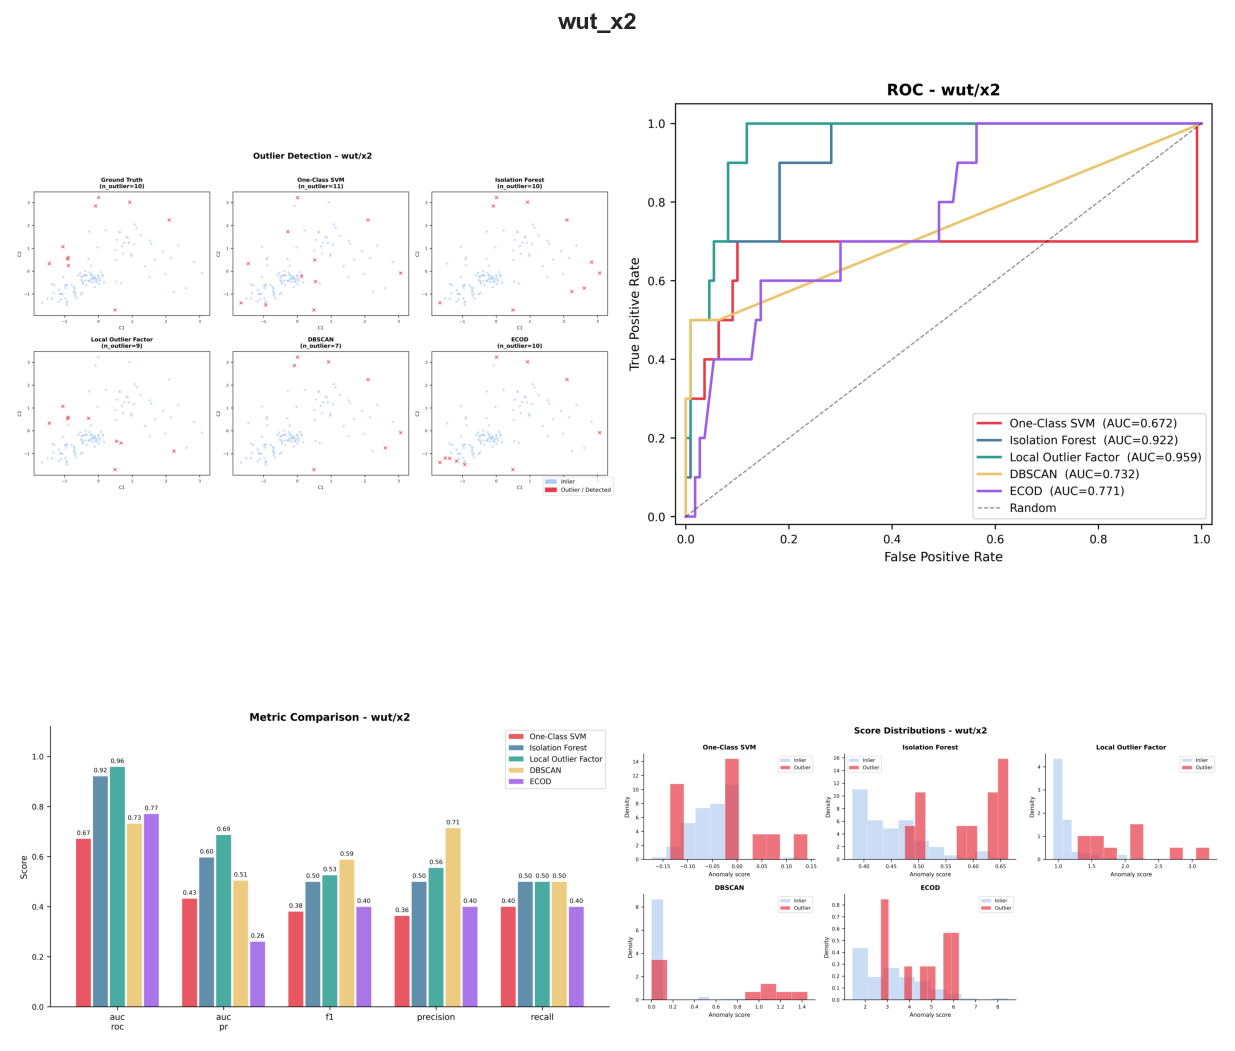

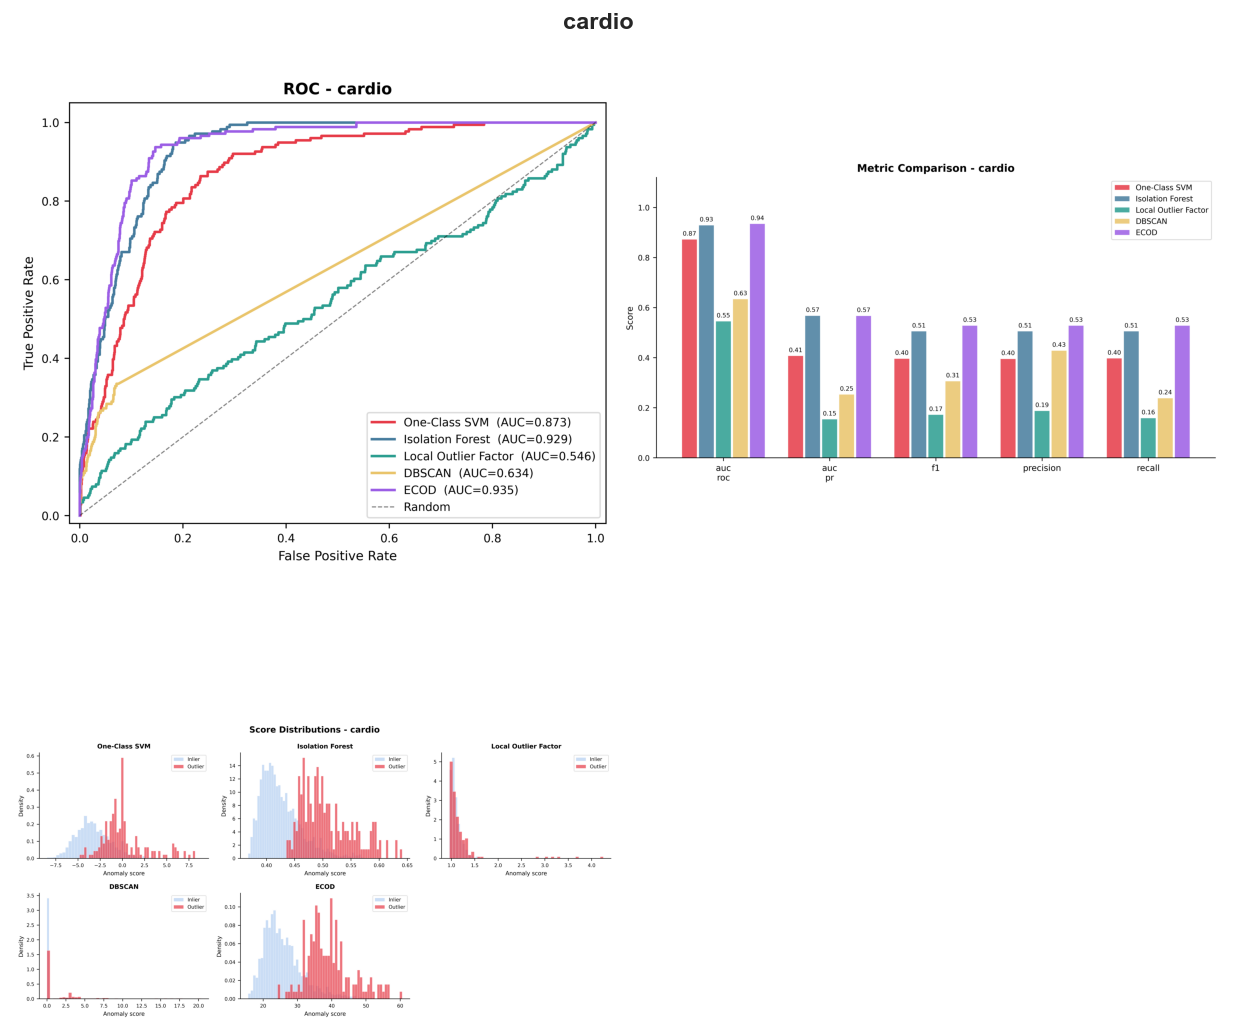

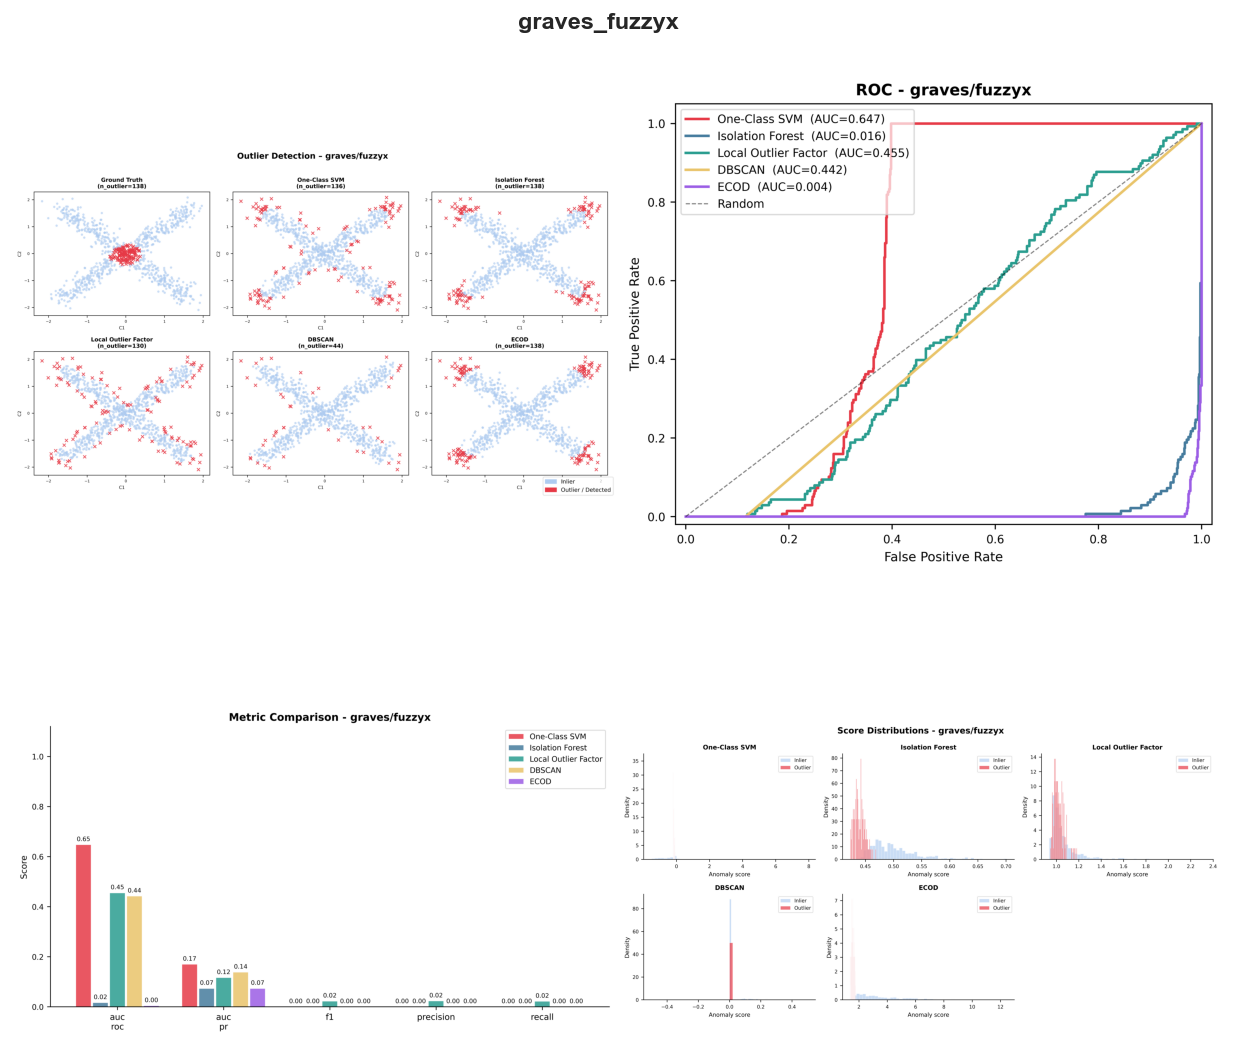

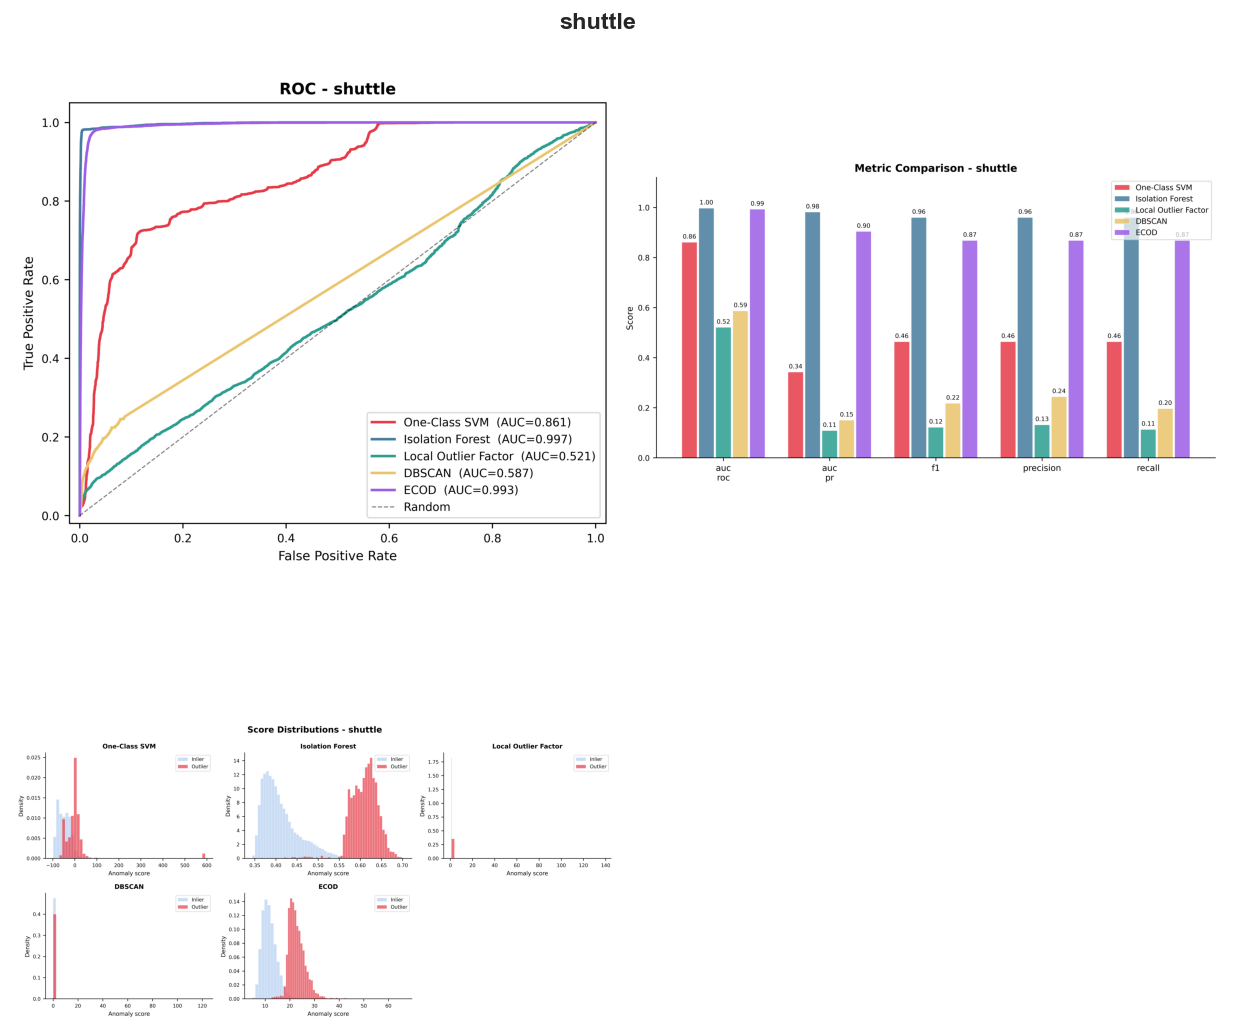

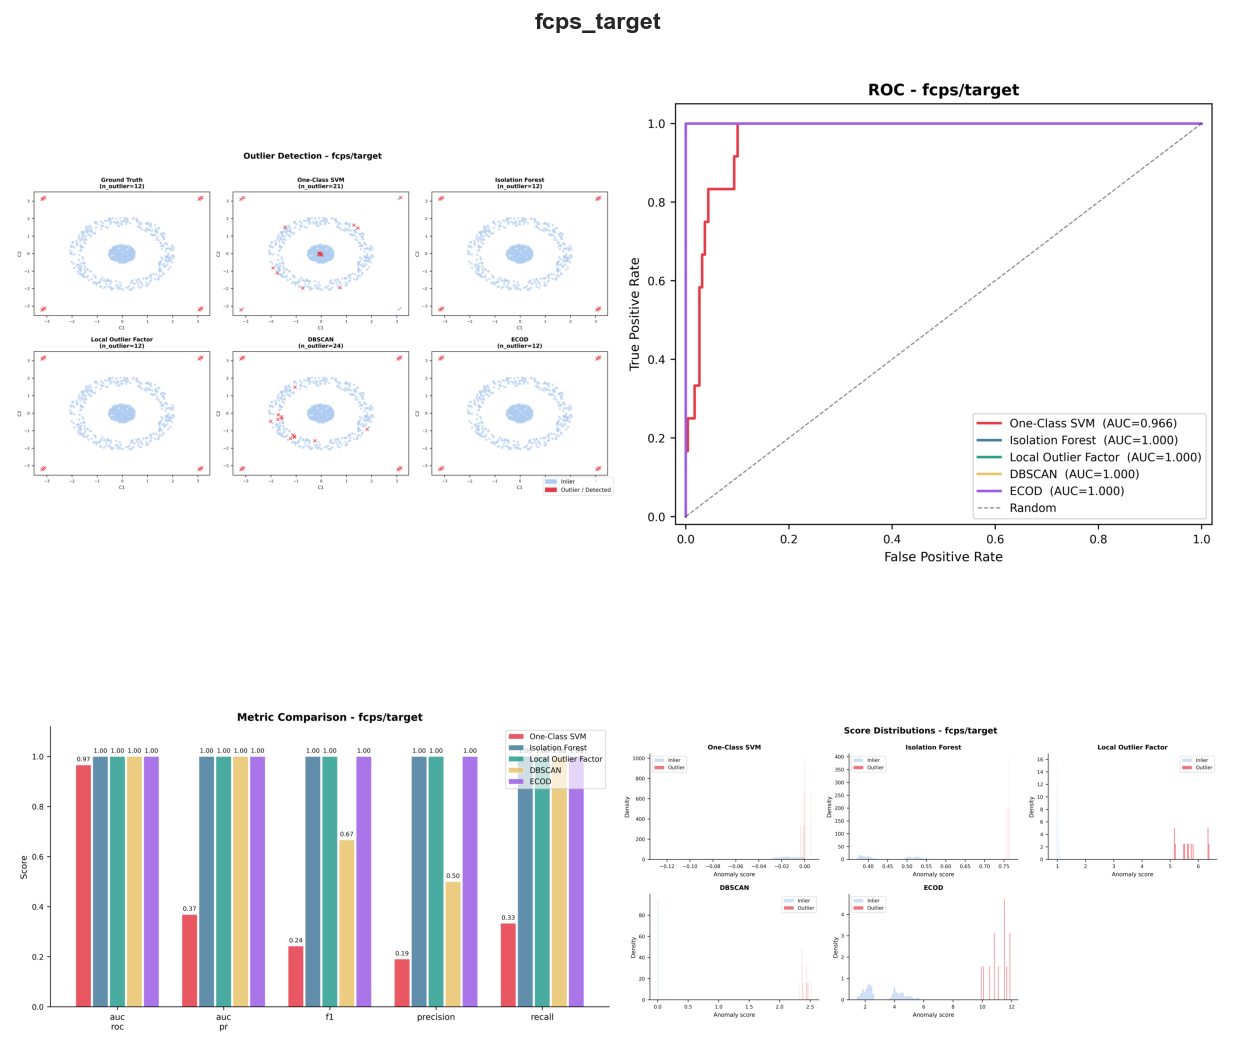

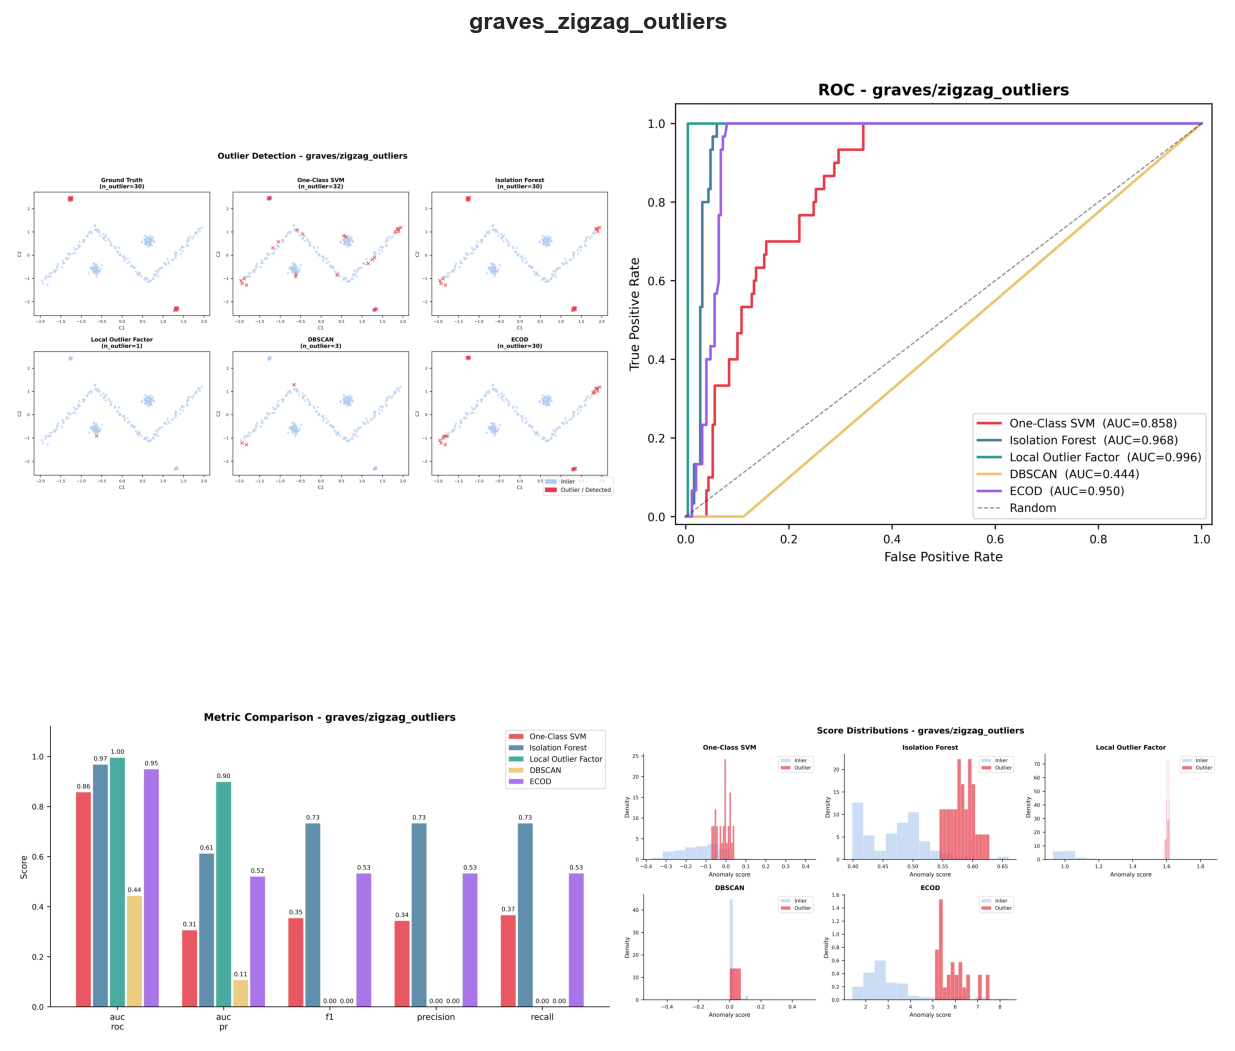

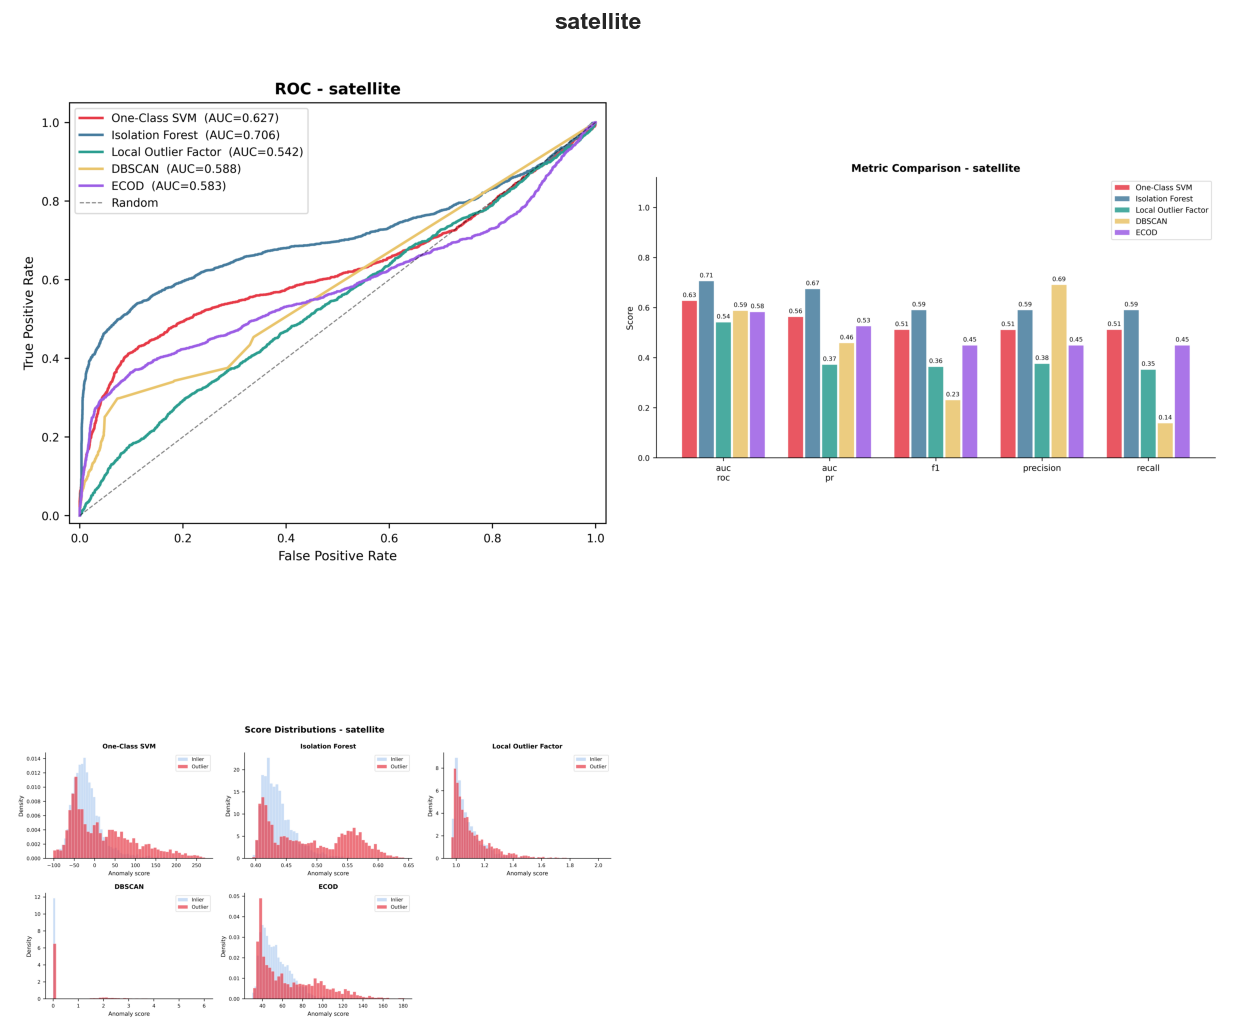

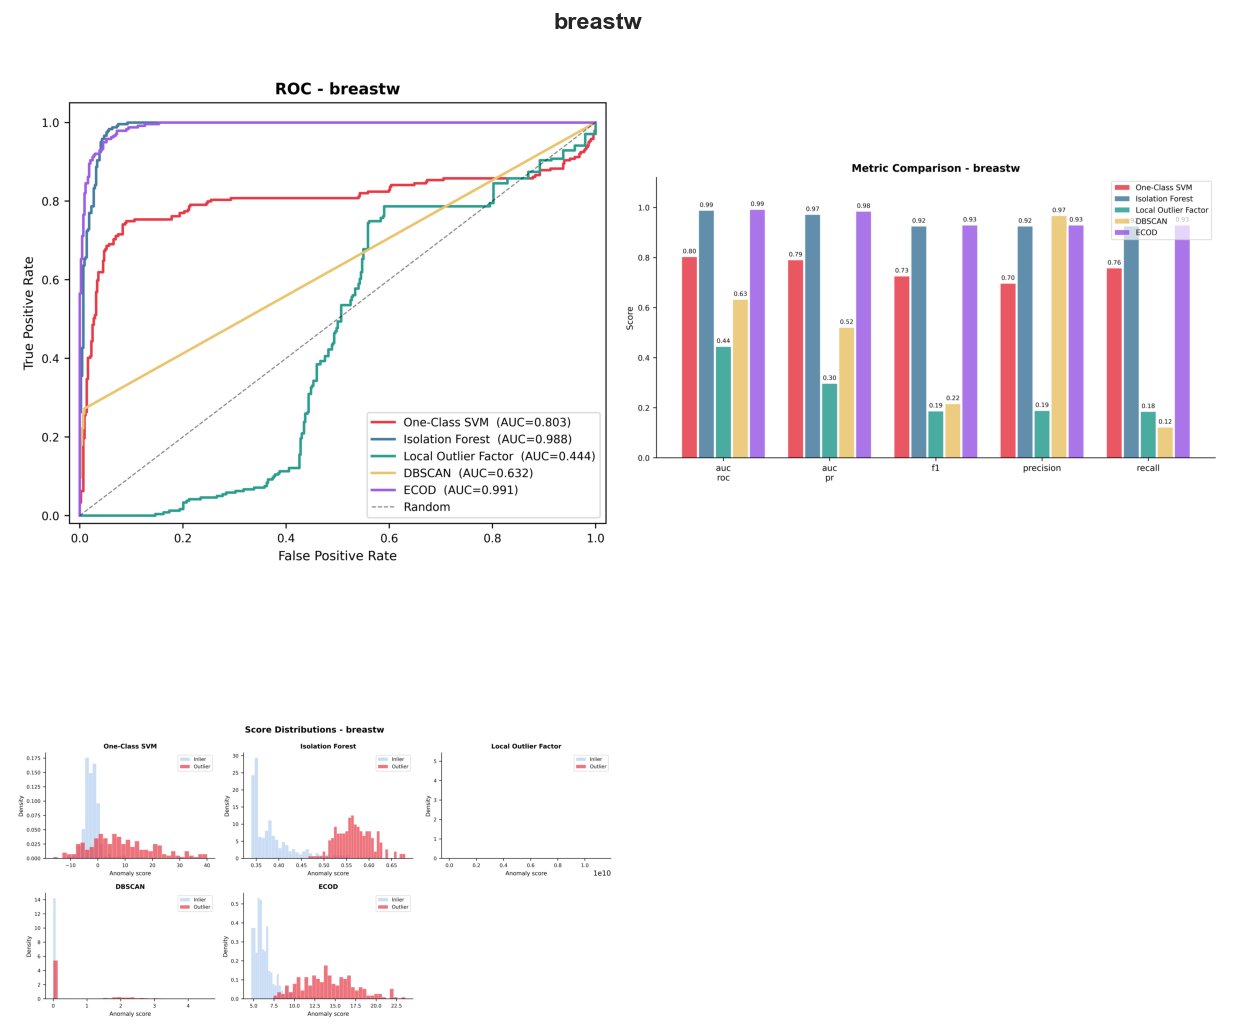

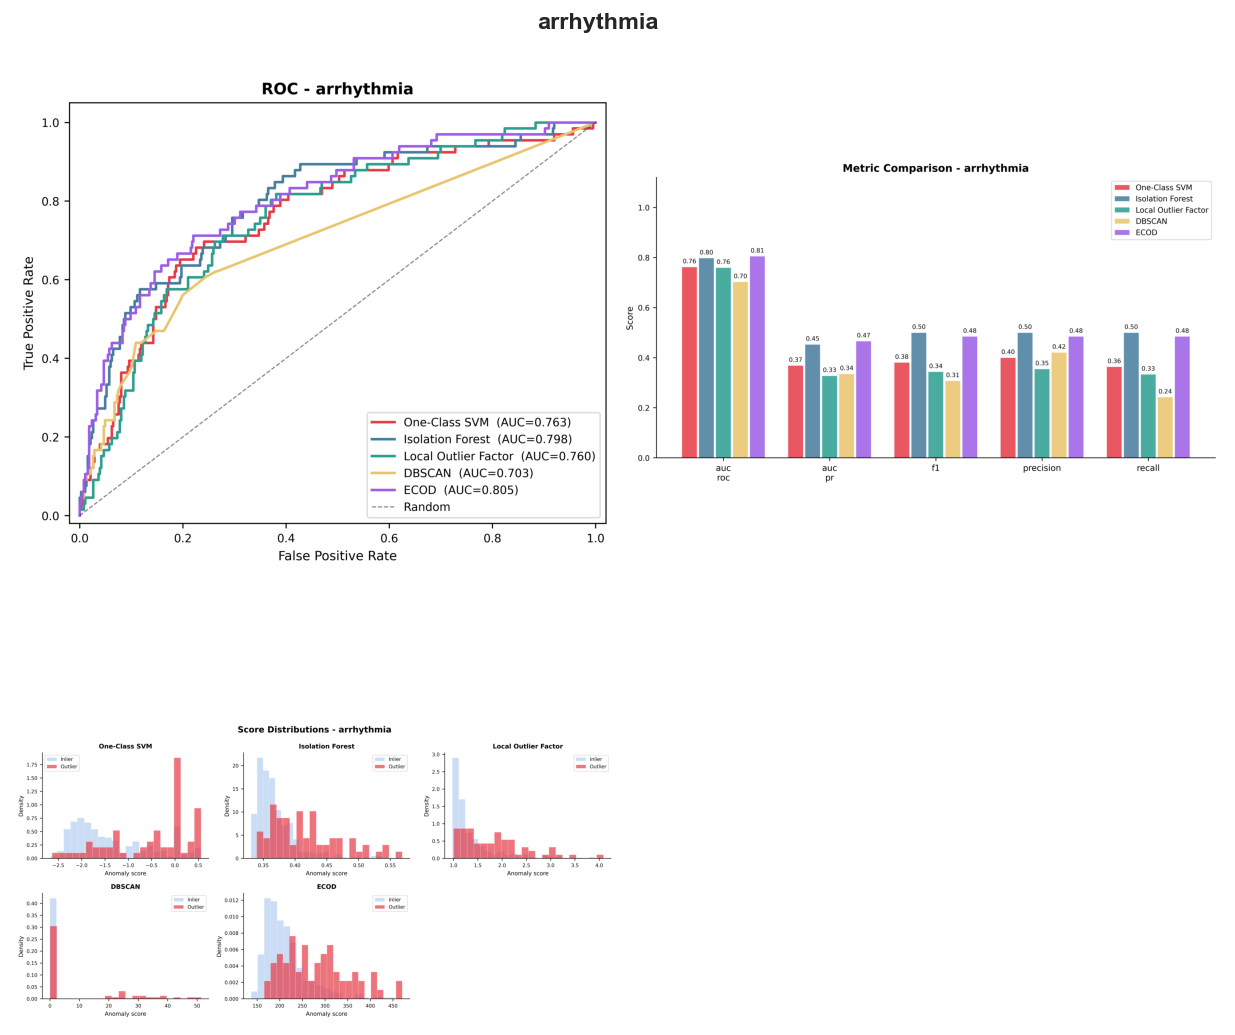

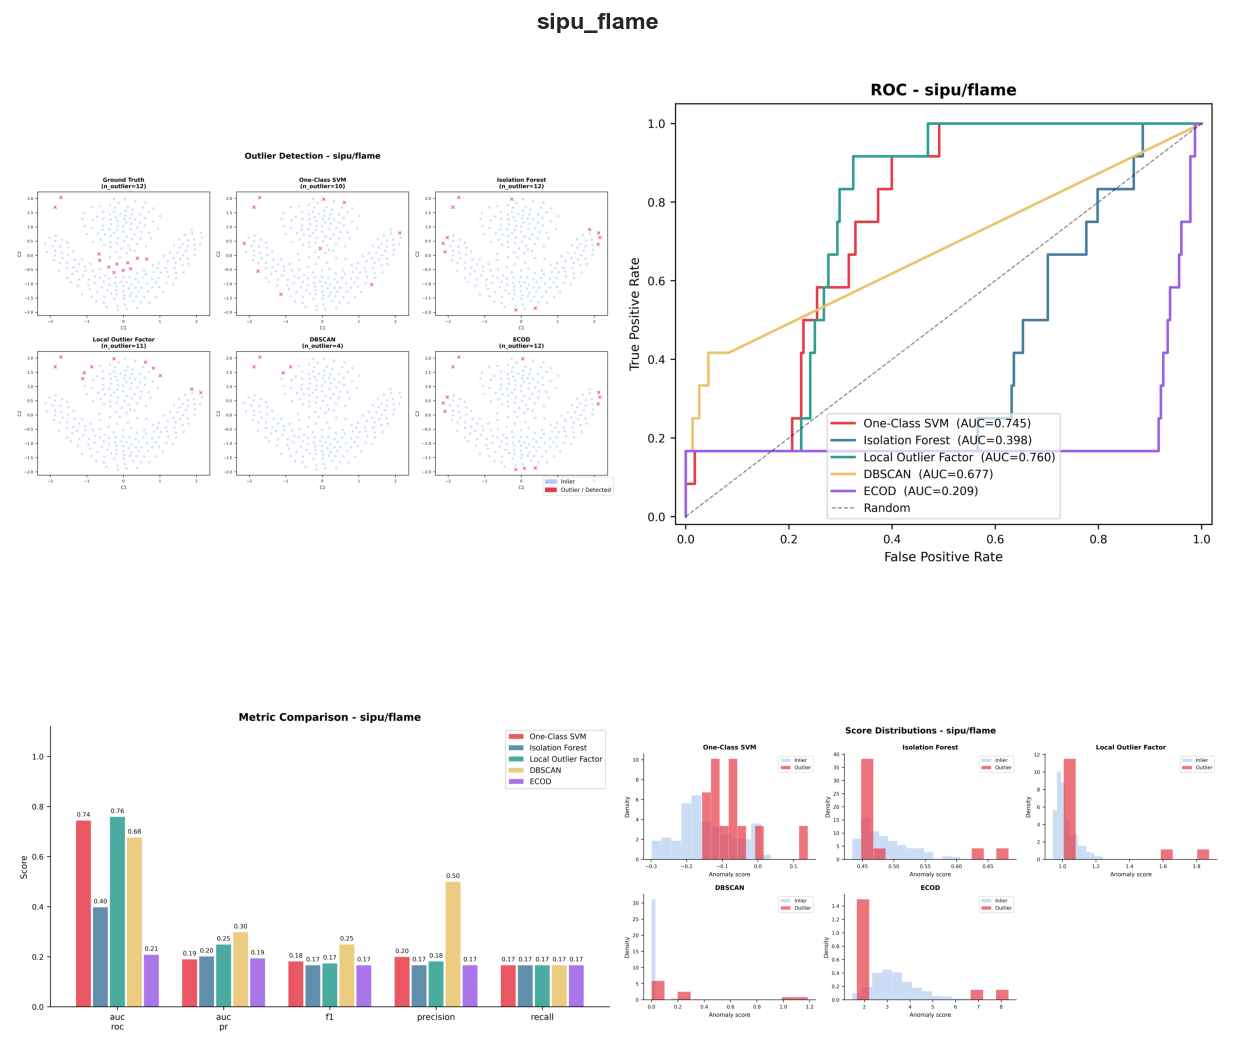

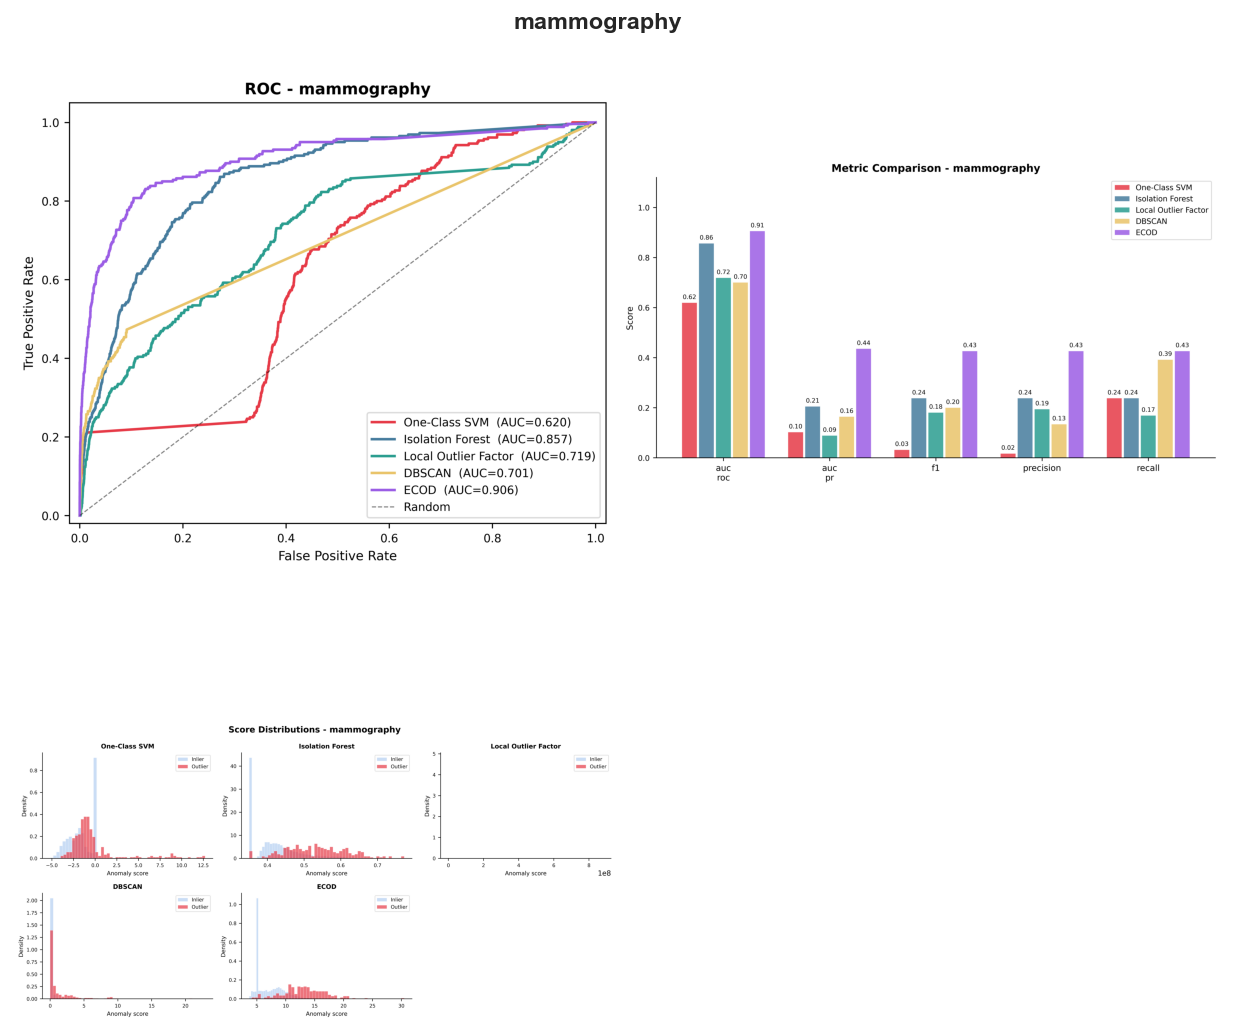

In [8]:
CLUSTERING = {"graves_ring_outliers", "graves_zigzag_outliers",  "graves_fuzzyx", "wut_x2", "fcps_target", "sipu_flame",}
for ds in all_results:
    plots = ["scatter", "roc", "metric_bars", "score_dist"] if ds in CLUSTERING else ["roc", "metric_bars", "score_dist"]
    show_dataset_summary(ds, plots)

## Takeaways

**Overall ranking:** Isolation Forest and ECOD tend to be the most consistent across datasets. LOF and DBSCAN show the highest variance.

**Hardest datasets:** graves_fuzzyx consistently resists all algorithms - its fuzzy, overlapping structure means there is no clean boundary between normal and anomalous. sipu_flame is similarly difficult: cluster-based structure confuses global detectors.

**Local vs global outliers:** DBSCAN and LOF detect local outliers well (ring, zigzag datasets) but struggle on high-dimensional tabular data (arrhythmia, satellite) where density estimation breaks down. Isolation Forest and ECOD handle global outliers better
and scale better with dimensionality.